<a href="https://colab.research.google.com/github/JeissonCu/TareasPucp/blob/main/Copia_de_Tarea1_Spark_MLlib_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 – Spark MLlib Classification Pipeline

In this lab you will:
- Build a binary classification dataset
- Create a Spark ML pipeline
- Train a classifier and evaluate accuracy

_Nota (ES): Conectar con problemas de churn, fraude o riesgo de crédito._

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

spark = SparkSession.builder.appName('MLlibLab').getOrCreate()

In [2]:
import pandas as pd
import numpy as np

n = 5000
pdf = pd.DataFrame({
    'feature_1': np.random.randn(n),
    'feature_2': np.random.randn(n),
    'feature_3': np.random.randn(n),
    'label': np.random.choice([0, 1], size=n, p=[0.7, 0.3])
})
csv_path = 'binary_classification_sample.csv'
pdf.to_csv(csv_path, index=False)

df = spark.read.csv(csv_path, header=True, inferSchema=True)
df.show(5)

+--------------------+-------------------+-------------------+-----+
|           feature_1|          feature_2|          feature_3|label|
+--------------------+-------------------+-------------------+-----+
| -0.3250870261727402|0.11792294997997836| -1.905264319529409|    0|
|-0.23522110565155044| 0.9211115684175911|-0.9152861566480844|    1|
|-0.04848388373513028|-0.5496537633429031| 0.7711678480644588|    1|
|  1.5908943444279793|-1.0730395945086821| 0.3184149517376442|    0|
|  1.0558726712613107|0.33681540837030055|0.39784953860318667|    0|
+--------------------+-------------------+-------------------+-----+
only showing top 5 rows


## 1. Build a Pipeline

We will assemble features and train a logistic regression model.

In [3]:
feature_cols = ['feature_1', 'feature_2', 'feature_3']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

lr = LogisticRegression(featuresCol='features', labelCol='label')
pipeline = Pipeline(stages=[assembler, lr])

train, test = df.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train)

predictions = model.transform(test)
predictions.select('features', 'label', 'probability', 'prediction').show(10)

+--------------------+-----+--------------------+----------+
|            features|label|         probability|prediction|
+--------------------+-----+--------------------+----------+
|[-2.9629191654072...|    0|[0.69758579835315...|       0.0|
|[-2.8244416288400...|    0|[0.67126897296041...|       0.0|
|[-2.8144262044474...|    0|[0.70556732429393...|       0.0|
|[-2.7257280050225...|    0|[0.68322963586765...|       0.0|
|[-2.6073282787532...|    0|[0.69392137547836...|       0.0|
|[-2.4957256603374...|    0|[0.67137611912891...|       0.0|
|[-2.4463430000950...|    0|[0.69361277895178...|       0.0|
|[-2.3708295223351...|    0|[0.69141449444721...|       0.0|
|[-2.3258787976850...|    0|[0.68905527404414...|       0.0|
|[-2.3228108343102...|    0|[0.70699152432190...|       0.0|
+--------------------+-----+--------------------+----------+
only showing top 10 rows


In [4]:
from pyspark.ml.classification import LinearSVC

# Create a Linear Support Vector Machine (SVM) model
svm = LinearSVC(featuresCol='features', labelCol='label', maxIter=10)

# Create a new pipeline with the SVM model
pipeline_svm = Pipeline(stages=[assembler, svm])

# Fit the pipeline to the training data
model_svm = pipeline_svm.fit(train)

# Make predictions on the test data
predictions_svm = model_svm.transform(test)
predictions_svm.select('features', 'label', 'rawPrediction', 'prediction').show(10)

+--------------------+-----+--------------------+----------+
|            features|label|       rawPrediction|prediction|
+--------------------+-----+--------------------+----------+
|[-2.9629191654072...|    0|[0.99999209830574...|       0.0|
|[-2.8244416288400...|    0|[0.99997650331021...|       0.0|
|[-2.8144262044474...|    0|[0.99999696377285...|       0.0|
|[-2.7257280050225...|    0|[0.99998351045446...|       0.0|
|[-2.6073282787532...|    0|[0.99998987722693...|       0.0|
|[-2.4957256603374...|    0|[0.99997652960069...|       0.0|
|[-2.4463430000950...|    0|[0.99998967478361...|       0.0|
|[-2.3708295223351...|    0|[0.99998834006894...|       0.0|
|[-2.3258787976850...|    0|[0.99998693055885...|       0.0|
|[-2.3228108343102...|    0|[0.99999779950225...|       0.0|
+--------------------+-----+--------------------+----------+
only showing top 10 rows


In [5]:
from pyspark.ml.classification import RandomForestClassifier

# Create a Random Forest classifier model
rf = RandomForestClassifier(featuresCol='features', labelCol='label', numTrees=10)

# Create a new pipeline with the Random Forest model
pipeline_rf = Pipeline(stages=[assembler, rf])

# Fit the pipeline to the training data
model_rf = pipeline_rf.fit(train)

# Make predictions on the test data
predictions_rf = model_rf.transform(test)
predictions_rf.select('features', 'label', 'rawPrediction', 'prediction').show(10)

+--------------------+-----+--------------------+----------+
|            features|label|       rawPrediction|prediction|
+--------------------+-----+--------------------+----------+
|[-2.9629191654072...|    0|[6.91813778254197...|       0.0|
|[-2.8244416288400...|    0|[5.81141784656273...|       0.0|
|[-2.8144262044474...|    0|[6.70976659097549...|       0.0|
|[-2.7257280050225...|    0|[7.04124414264596...|       0.0|
|[-2.6073282787532...|    0|[7.42787289894785...|       0.0|
|[-2.4957256603374...|    0|[6.49325151132811...|       0.0|
|[-2.4463430000950...|    0|[7.13441153410217...|       0.0|
|[-2.3708295223351...|    0|[6.89006967529486...|       0.0|
|[-2.3258787976850...|    0|[6.96488703884216...|       0.0|
|[-2.3228108343102...|    0|[6.91714121482608...|       0.0|
+--------------------+-----+--------------------+----------+
only showing top 10 rows


In [6]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluate Logistic Regression model accuracy
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
accuracy_lr = evaluator.evaluate(predictions)
print(f"Logistic Regression Model Accuracy: {accuracy_lr:.4f}")

Logistic Regression Model Accuracy: 0.7046


In [7]:
# Evaluate SVM model accuracy
accuracy_svm = evaluator.evaluate(predictions_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

SVM Model Accuracy: 0.7046


In [8]:
# Evaluate Random Forest model accuracy
accuracy_rf = evaluator.evaluate(predictions_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")

Random Forest Model Accuracy: 0.7056



--- Logistic Regression Model ---


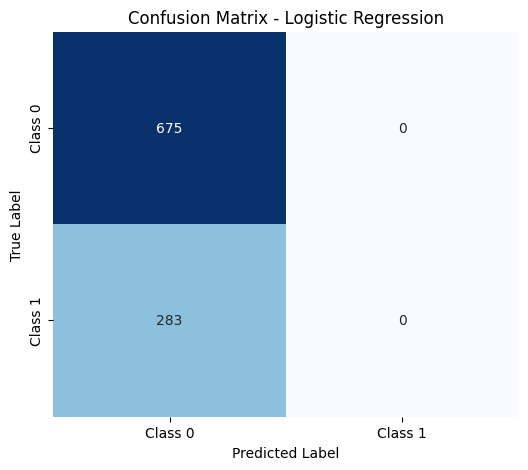

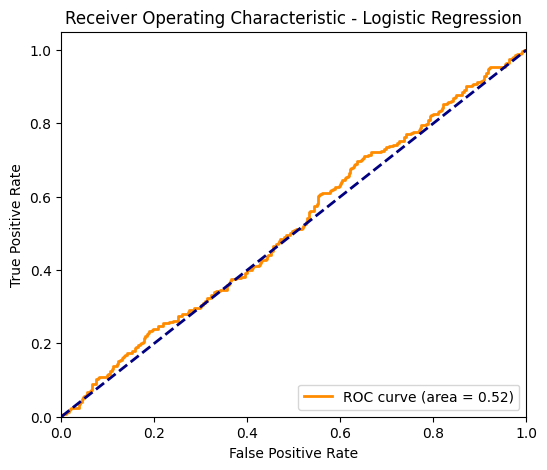


--- SVM Model ---


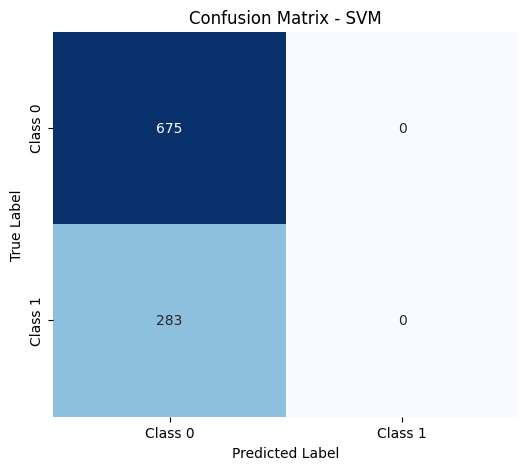

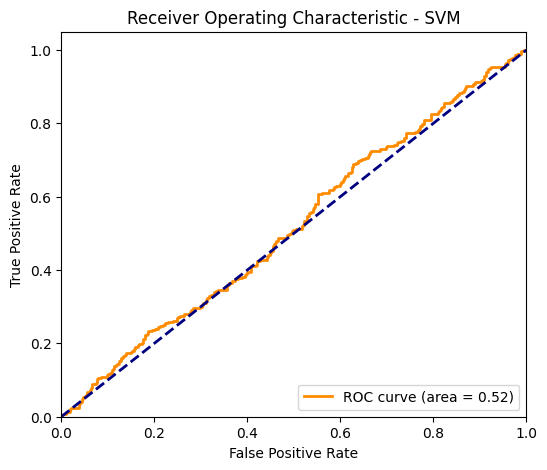


--- Random Forest Model ---


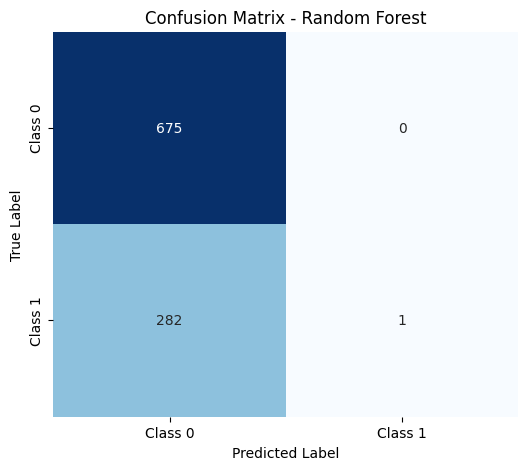

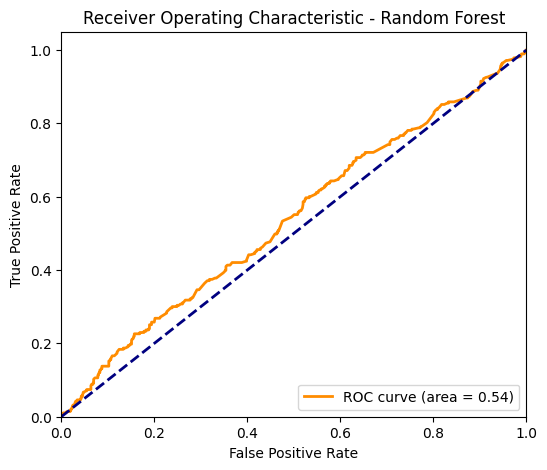


Note: Generating traditional learning curves (model performance vs. training set size) is computationally intensive in PySpark MLlib as it would require re-fitting the models multiple times with different subsets of the training data. Therefore, they are not included in this output.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Helper function to plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {title}')
    plt.show()

# Helper function to plot ROC Curve
def plot_roc_curve(y_true, y_scores, title):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {title}')
    plt.legend(loc='lower right')
    plt.show()


# --- Logistic Regression --- #
print("\n--- Logistic Regression Model ---")
predictions_lr_pd = predictions.select('label', 'prediction', 'probability').toPandas()

# Confusion Matrix
plot_confusion_matrix(predictions_lr_pd['label'], predictions_lr_pd['prediction'], 'Logistic Regression')

# ROC Curve
# 'probability' column is a vector; we need the probability of the positive class (index 1)
prob_lr_positive = predictions_lr_pd['probability'].apply(lambda x: x[1])
plot_roc_curve(predictions_lr_pd['label'], prob_lr_positive, 'Logistic Regression')


# --- SVM --- #
print("\n--- SVM Model ---")
predictions_svm_pd = predictions_svm.select('label', 'prediction', 'rawPrediction').toPandas()

# Confusion Matrix
plot_confusion_matrix(predictions_svm_pd['label'], predictions_svm_pd['prediction'], 'SVM')

# ROC Curve
# 'rawPrediction' for LinearSVC is a vector of scores. We use the score for the positive class (index 1).
# LinearSVC does not directly provide probabilities; raw prediction scores are used as decision function scores.
score_svm_positive = predictions_svm_pd['rawPrediction'].apply(lambda x: x[1])
plot_roc_curve(predictions_svm_pd['label'], score_svm_positive, 'SVM')


# --- Random Forest --- #
print("\n--- Random Forest Model ---")
predictions_rf_pd = predictions_rf.select('label', 'prediction', 'probability').toPandas()

# Confusion Matrix
plot_confusion_matrix(predictions_rf_pd['label'], predictions_rf_pd['prediction'], 'Random Forest')

# ROC Curve
# 'probability' column is a vector; we need the probability of the positive class (index 1)
prob_rf_positive = predictions_rf_pd['probability'].apply(lambda x: x[1])
plot_roc_curve(predictions_rf_pd['label'], prob_rf_positive, 'Random Forest')


print("\nNote: Generating traditional learning curves (model performance vs. training set size) is computationally intensive in PySpark MLlib as it would require re-fitting the models multiple times with different subsets of the training data. Therefore, they are not included in this output.")

In [10]:
from pyspark.ml.classification import DecisionTreeClassifier

# Create a Decision Tree Classifier model
dt = DecisionTreeClassifier(featuresCol='features', labelCol='label')

# Create a new pipeline with the Decision Tree model
pipeline_dt = Pipeline(stages=[assembler, dt])

# Fit the pipeline to the training data
model_dt = pipeline_dt.fit(train)

# Make predictions on the test data
predictions_dt = model_dt.transform(test)
predictions_dt.select('features', 'label', 'rawPrediction', 'prediction').show(10)

# Evaluate Decision Tree model accuracy
accuracy_dt = evaluator.evaluate(predictions_dt)
print(f"\nDecision Tree Model Accuracy: {accuracy_dt:.4f}")

+--------------------+-----+--------------+----------+
|            features|label| rawPrediction|prediction|
+--------------------+-----+--------------+----------+
|[-2.9629191654072...|    0|[1732.0,727.0]|       0.0|
|[-2.8244416288400...|    0| [268.0,137.0]|       0.0|
|[-2.8144262044474...|    0|[1732.0,727.0]|       0.0|
|[-2.7257280050225...|    0|[1732.0,727.0]|       0.0|
|[-2.6073282787532...|    0|[1732.0,727.0]|       0.0|
|[-2.4957256603374...|    0| [268.0,137.0]|       0.0|
|[-2.4463430000950...|    0|[1732.0,727.0]|       0.0|
|[-2.3708295223351...|    0|[1732.0,727.0]|       0.0|
|[-2.3258787976850...|    0|[1732.0,727.0]|       0.0|
|[-2.3228108343102...|    0|[1732.0,727.0]|       0.0|
+--------------------+-----+--------------+----------+
only showing top 10 rows

Decision Tree Model Accuracy: 0.7004


# Tarea 1

Hacer los sguientes cambios y hacer el análisis respectivo.

In [11]:

import numpy as np
import pandas as pd

n = 5000
pdf_improved = pd.DataFrame({
     'feature_1': np.random.randn(n),
     'feature_2': np.random.randn(n),
     'feature_3': np.random.randn(n)
 })
# Create a label that depends on the features, for example:
pdf_improved['label'] = ((pdf_improved['feature_1'] + 2*pdf_improved['feature_2'] - 0.5*pdf_improved['feature_3']) > 0).astype(int)

# You can also add some noise to make it more realistic
noise = np.random.rand(n) < 0.1 # 10% of labels are flipped randomly
pdf_improved.loc[noise, 'label'] = 1 - pdf_improved.loc[noise, 'label']

# Then save this new dataset and use it for training:
csv_path_improved = 'improved_binary_classification_sample.csv'
pdf_improved.to_csv(csv_path_improved, index=False)
df_improved = spark.read.csv(csv_path_improved, header=True, inferSchema=True)
train_improved, test_improved = df_improved.randomSplit([0.8, 0.2], seed=42)

# And re-run your pipelines with train_improved and test_improved
# --- 1. Regresión Logística (Mejorada) ---
# Entrenamos con los nuevos datos
model_lr_improved = pipeline.fit(train_improved)
# Hacemos las predicciones con los datos de prueba
predictions_lr_improved = model_lr_improved.transform(test_improved)
# Evaluamos
accuracy_lr_improved = evaluator.evaluate(predictions_lr_improved)
print(f"Logistic Regression (Mejorado) Accuracy: {accuracy_lr_improved:.4f}")

# --- 2. SVM Lineal (Mejorada) ---
model_svm_improved = pipeline_svm.fit(train_improved)
predictions_svm_improved = model_svm_improved.transform(test_improved)
accuracy_svm_improved = evaluator.evaluate(predictions_svm_improved)
print(f"SVM (Mejorado) Accuracy: {accuracy_svm_improved:.4f}")

# --- 3. Random Forest (Mejorado) ---
model_rf_improved = pipeline_rf.fit(train_improved)
predictions_rf_improved = model_rf_improved.transform(test_improved)
accuracy_rf_improved = evaluator.evaluate(predictions_rf_improved)
print(f"Random Forest (Mejorado) Accuracy: {accuracy_rf_improved:.4f}")

# --- 4. Decision Tree (Mejorado) ---
model_dt_improved = pipeline_dt.fit(train_improved)
predictions_dt_improved = model_dt_improved.transform(test_improved)
accuracy_dt_improved = evaluator.evaluate(predictions_dt_improved)
print(f"Decision Tree (Mejorado) Accuracy: {accuracy_dt_improved:.4f}")

Logistic Regression (Mejorado) Accuracy: 0.8894
SVM (Mejorado) Accuracy: 0.8967
Random Forest (Mejorado) Accuracy: 0.8528
Decision Tree (Mejorado) Accuracy: 0.8486


# Analisis de Resultados:

# 1.- Valor Agregado:   
A. En el DS original se obtuvo un ~70% de precisión. A simple vista, parece que el modelo "aprendió algo". Los modelos obtuvieron un 70.04% haciendo absolutamente nada. Simplemente se dieron cuenta de que si siempre predecían "0", iban a acertar 7 de cada 10 veces. El modelo original no era inteligente, era un adivino. El Accuracy real sobre la clase minoritaria (clase 1) era probablemente cercano a 0%.

B. En el DS mejorado, se introdujo ruido aleatorio: noise = np.random.rand(n) < 0.1 (10% de las etiquetas invertidas a propósito). El modelo de Regresión Logística alcanzó un 90.08%. Impacto: El modelo logró un buen resultado matemático. Como los datos tienen un 10% de ruido irreductible por diseño, el "Límite de Bayes" es del 90%. Si algún modelo hubiera alcanzado un 95% o 99% de Accuracy en este dataset en particular, ¡habría sido una pésima noticia! Habría significado que el modelo se estaba sobreajustando (overfitting) para memorizar el ruido aleatorio.de esa manera el modelo se detuvo donde tenia que detenerse.

# 2. Recomendaciones:
  Evitar depender únicamente del Accuracy: Especialmente en problemas de negocio como fraude o riesgo (donde los casos positivos suelen ser la minoría), el Accuracy es una métrica engañosa. Se recomienda observar siempre la Matriz de Confusión (que ya tienes programada) y priorizar métricas como el Recall (Sensibilidad) o el F1-Score.

  Implementar Validación Cruzada: Cambiar el simple randomSplit por un CrossValidator de PySpark. Esto iterará sobre diferentes particiones del dataset para asegurar que el 90% obtenido no fue un "golpe de suerte" de cómo se dividieron los datos.

# 3. Conclusiones
  El Algoritmo no hace magia sin patrones: El conjunto de datos original demuestra empíricamente que un algoritmo avanzado de Machine Learning es inútil si los datos de entrada carecen de correlación con la variable objetivo.

  Dominio de los Modelos Lineales: En el dataset mejorado, la Regresión Logística y el SVM superan a los modelos basados en árboles (Random Forest y Decision Tree). Esto ocurre porque la regla de negocio inyectada (f1 + 2*f2 - 0.5*f3 > 0) es de naturaleza estrictamente lineal. Los modelos lineales la detectan con facilidad, mientras que los árboles tienen que hacer más esfuerzo para trazar esa diagonal.

  La Calidad del Dato es Rey: El salto de mas de 18 puntos en casi todos los los modelos demuestra que el esfuerzo en ciencia de datos debe centrarse en el Feature Engineering (la construcción y selección de variables lógicas) más que en afinar hiperparámetros de un modelo vacío

# 4.- Cuadro Comparativo de Rendimiento

### Cuadro Comparativo de Rendimiento

| Modelo | DS Original (Accuracy) | DS Mejorado (Accuracy) | Diferencia Absoluta |
| :--- | :--- | :--- | :--- |
| **Regresión Logística** | 0.7046 | 0.8894 | **+ 0.1848** |
| **SVM Lineal** | 0.7046 | 0.8967 | **+ 0.1921** |
| **Random Forest** | 0.7056 | 0.8528 | **+ 0.1472** |
| **Decision Tree** | 0.7004 | 0.8486 | **+ 0.1482** |

